In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/AutoInsurance.csv")

In [6]:
df.info()
custcolumn=df['Customer']
effectivedatecolumn=df['Effective To Date']
df=df.drop(columns=['Customer','Effective To Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   State                          9134 non-null   object 
 1   Customer Lifetime Value        9134 non-null   float64
 2   Response                       9134 non-null   object 
 3   Coverage                       9134 non-null   object 
 4   Education                      9134 non-null   object 
 5   EmploymentStatus               9134 non-null   object 
 6   Gender                         9134 non-null   object 
 7   Income                         9134 non-null   int64  
 8   Location Code                  9134 non-null   object 
 9   Marital Status                 9134 non-null   object 
 10  Monthly Premium Auto           9134 non-null   int64  
 11  Months Since Last Claim        9134 non-null   int64  
 12  Months Since Policy Inception  9134 non-null   i

In [8]:
df.shape


(9134, 22)

In [9]:
df.describe()

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,37657.380009,93.219291,15.097000,48.064594,0.384388,2.966170,434.088794
std,6870.967608,30379.904734,34.407967,10.073257,27.905991,0.910384,2.390182,290.500092
min,1898.007675,0.000000,61.000000,0.000000,0.000000,0.000000,1.000000,0.099007
25%,3994.251794,0.000000,68.000000,6.000000,24.000000,0.000000,1.000000,272.258244
50%,5780.182197,33889.500000,83.000000,14.000000,48.000000,0.000000,2.000000,383.945434
75%,8962.167041,62320.000000,109.000000,23.000000,71.000000,0.000000,4.000000,547.514839
max,83325.381190,99981.000000,298.000000,35.000000,99.000000,5.000000,9.000000,2893.239678


<Axes: xlabel='State', ylabel='count'>

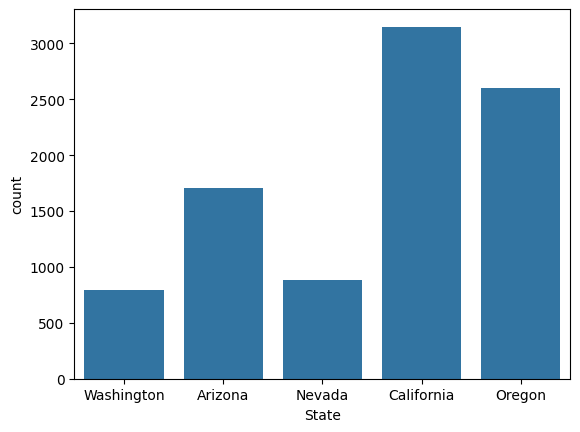

In [10]:
sns.countplot(x='State', data=df)

<Axes: ylabel='Income'>

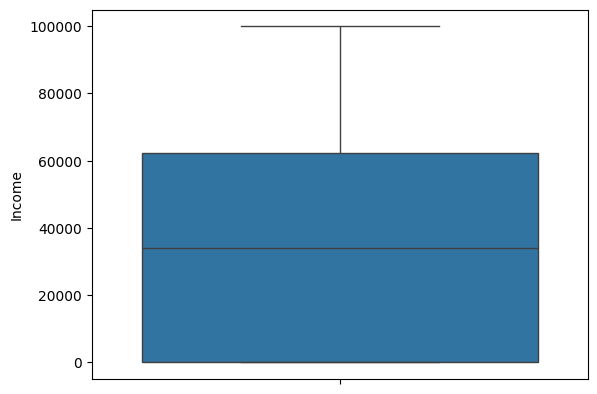

In [11]:
sns.boxplot(y=df['Income'])

<Axes: xlabel='Coverage', ylabel='Customer Lifetime Value'>

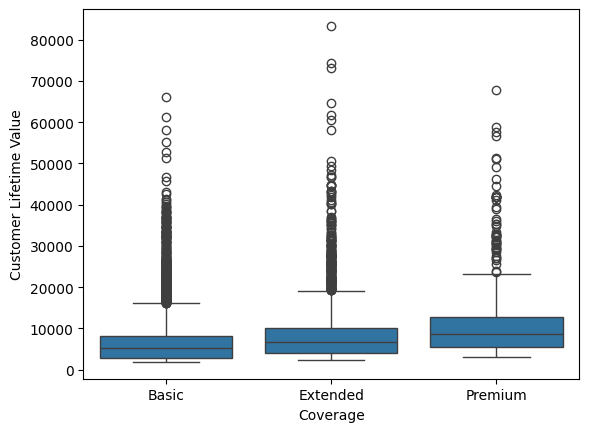

In [12]:
sns.boxplot(x='Coverage', y='Customer Lifetime Value', data=df)

<Axes: xlabel='Income', ylabel='Customer Lifetime Value'>

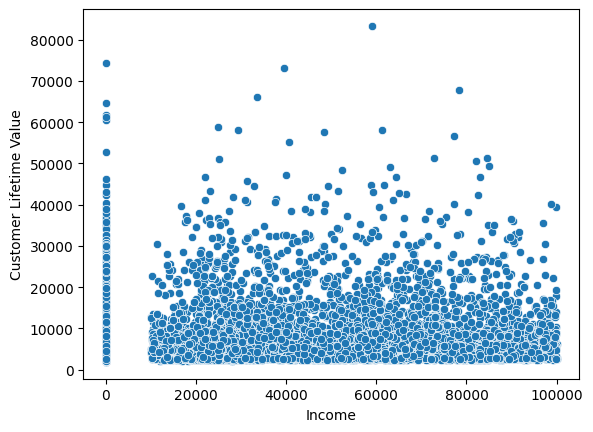

In [13]:
sns.scatterplot(x='Income', y='Customer Lifetime Value', data=df)

<Axes: >

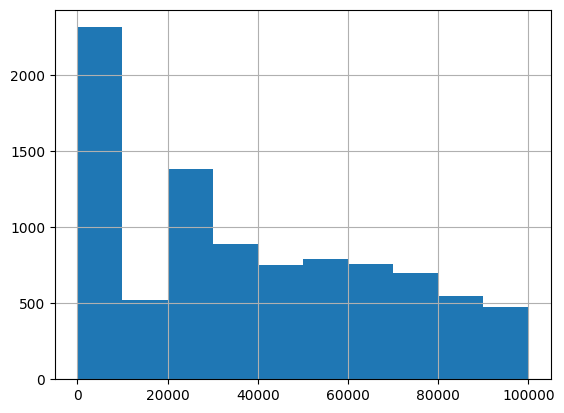

In [15]:
df['Income'].hist()

In [16]:
# Separate columns by type
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

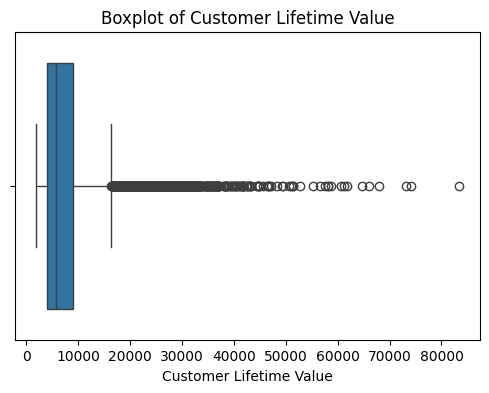

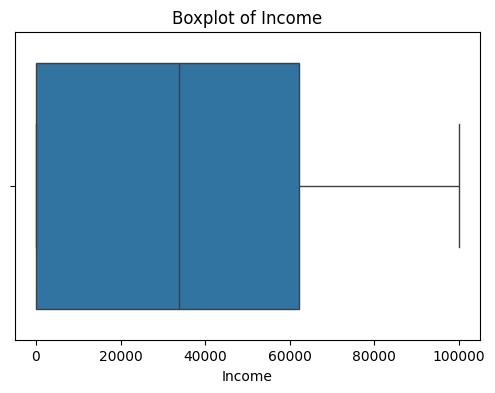

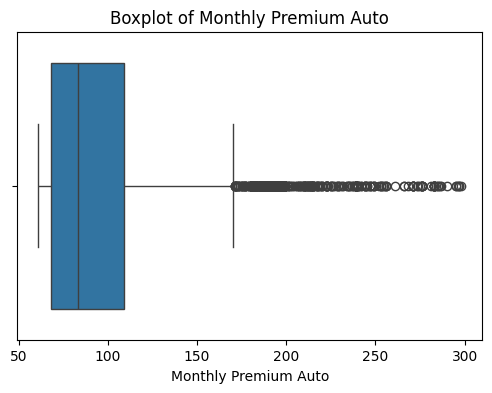

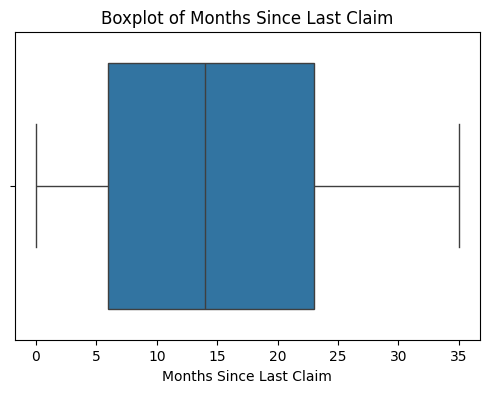

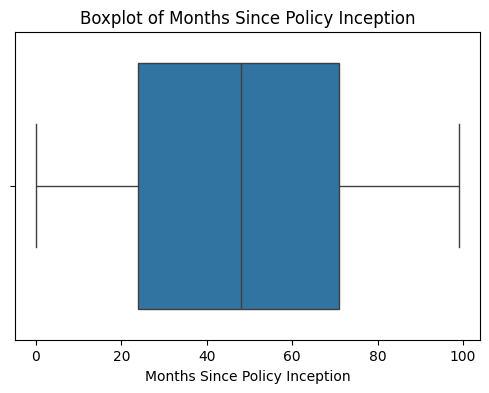

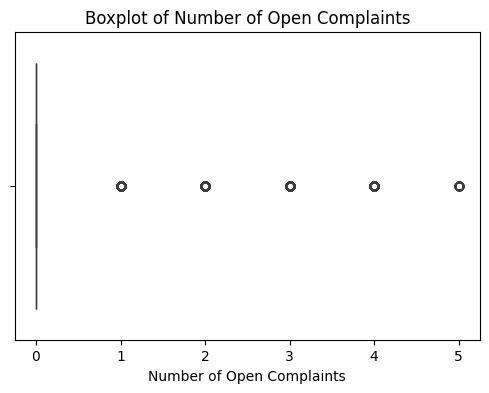

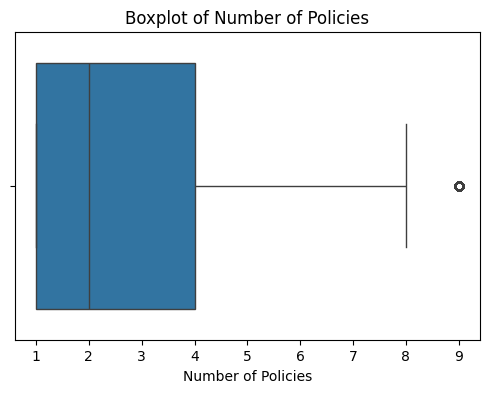

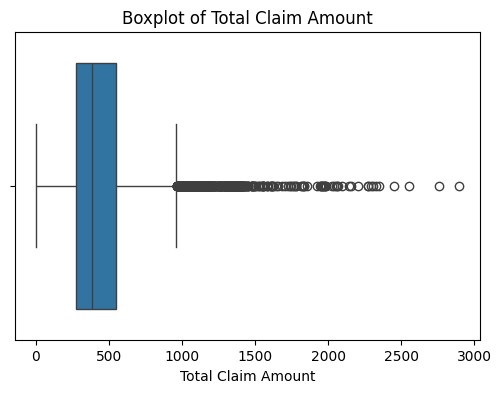

In [25]:
# --- Boxplot for all numerical columns ---
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


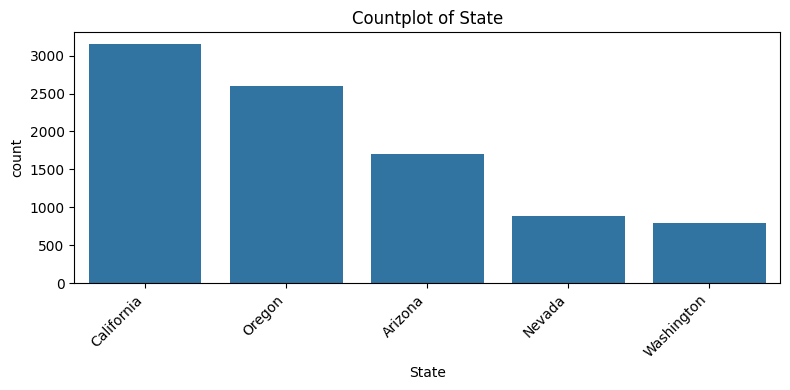

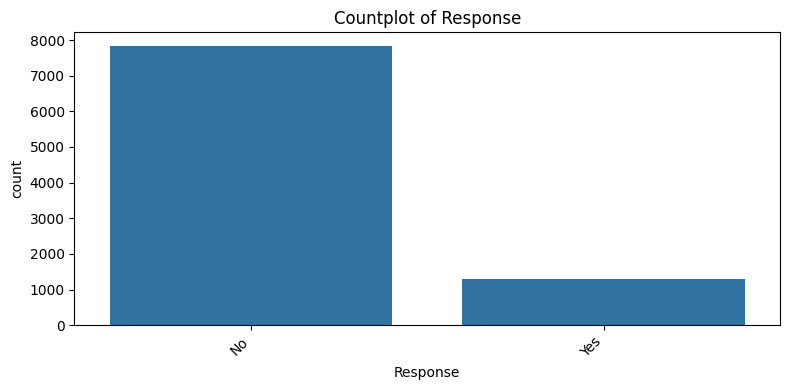

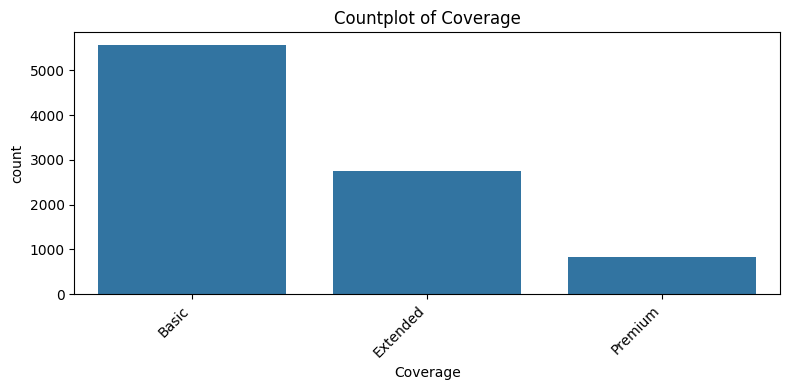

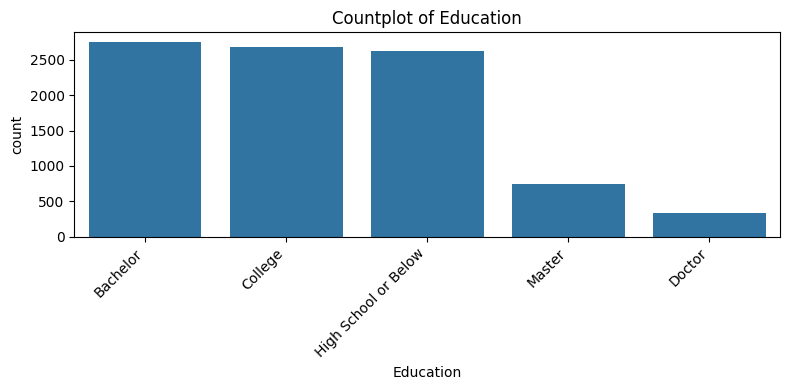

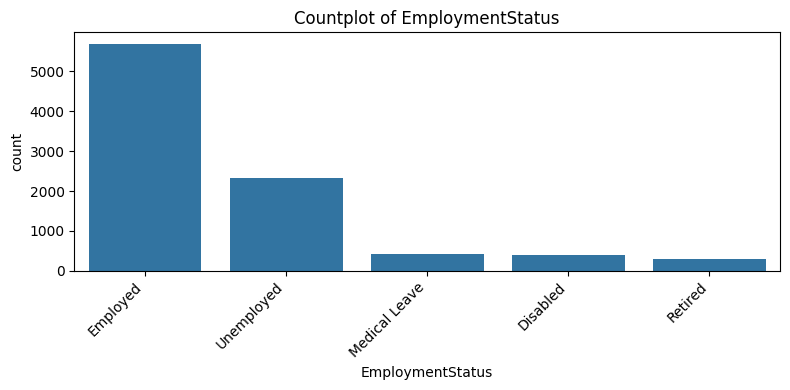

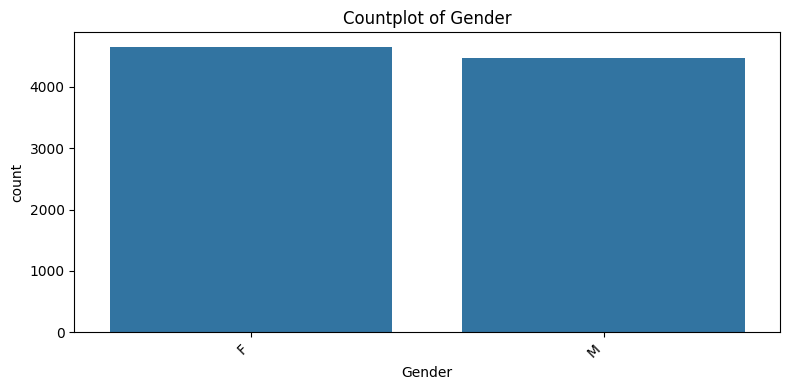

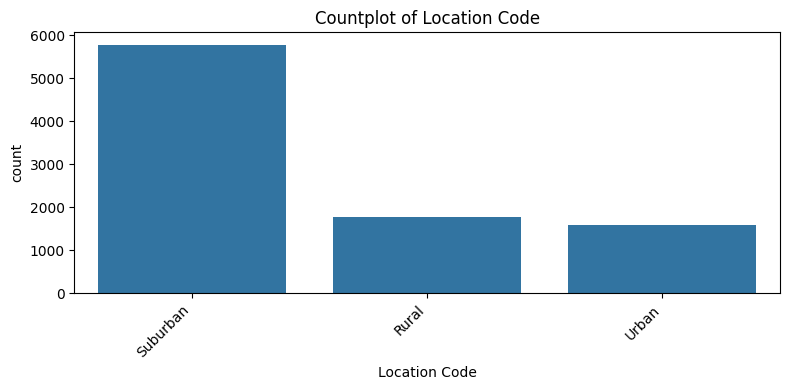

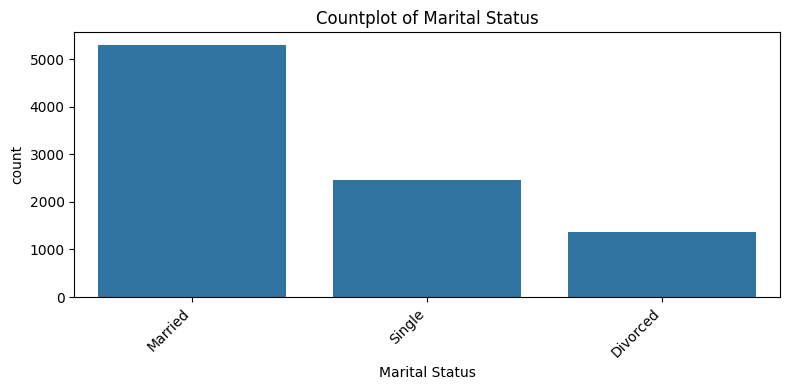

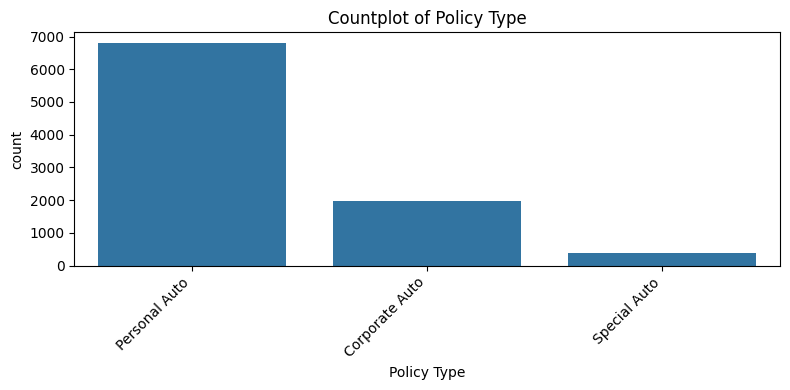

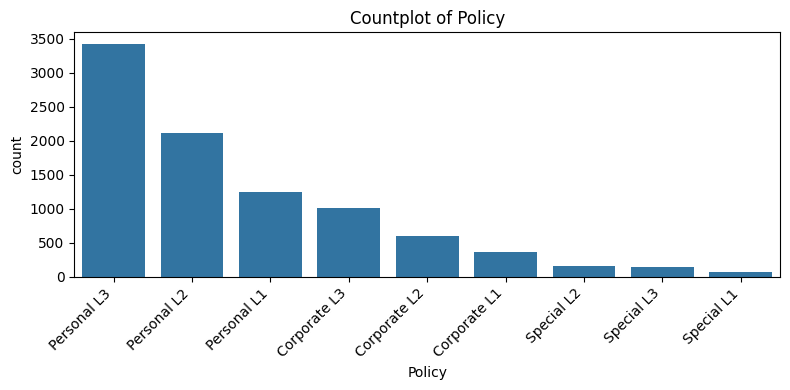

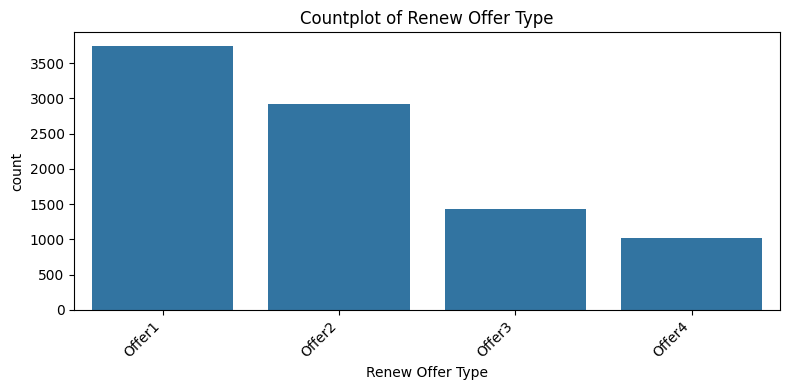

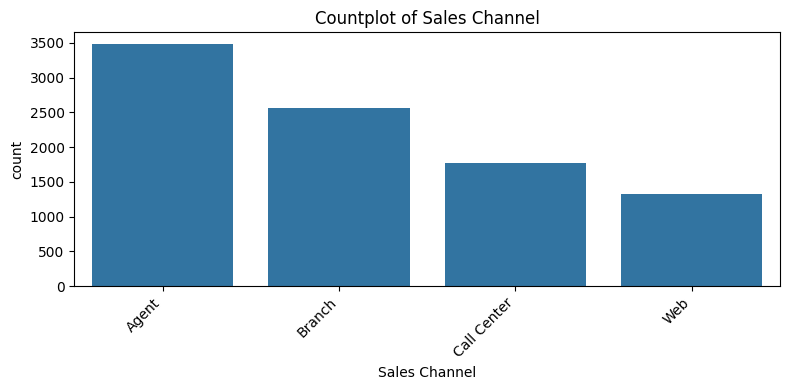

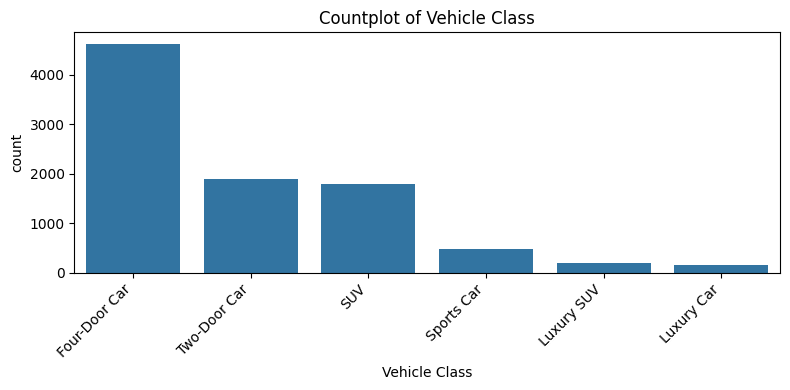

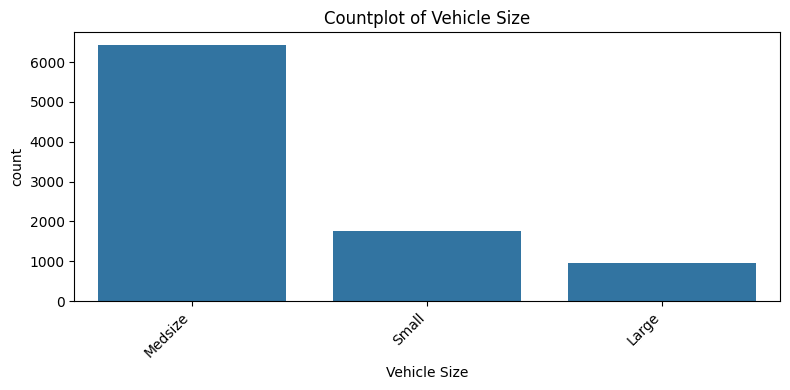

In [18]:
# --- Countplot for all categorical columns ---
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

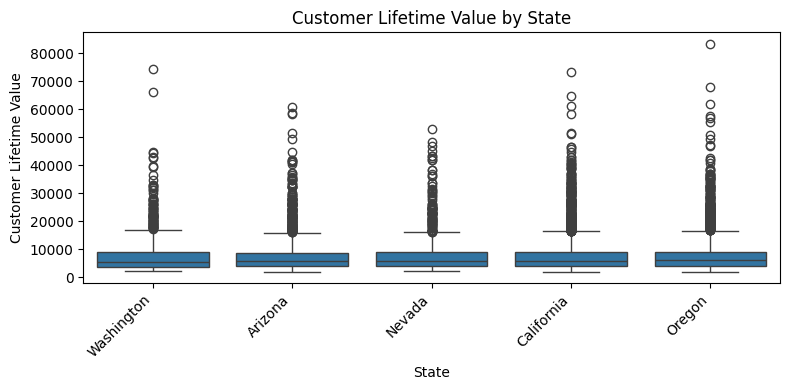

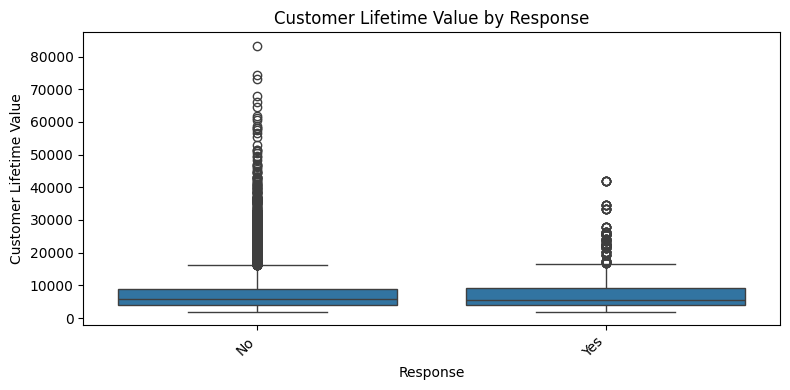

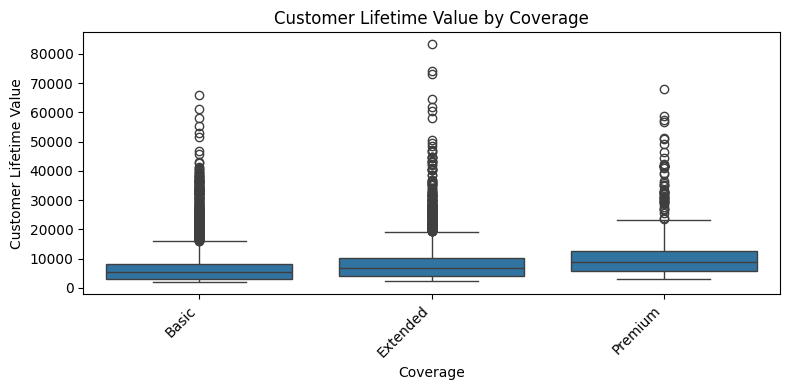

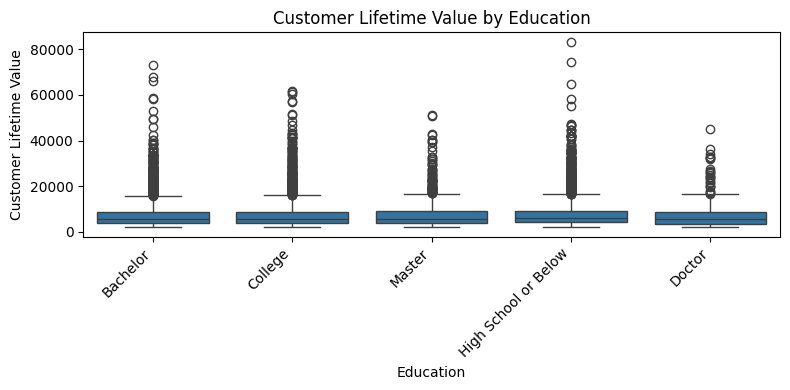

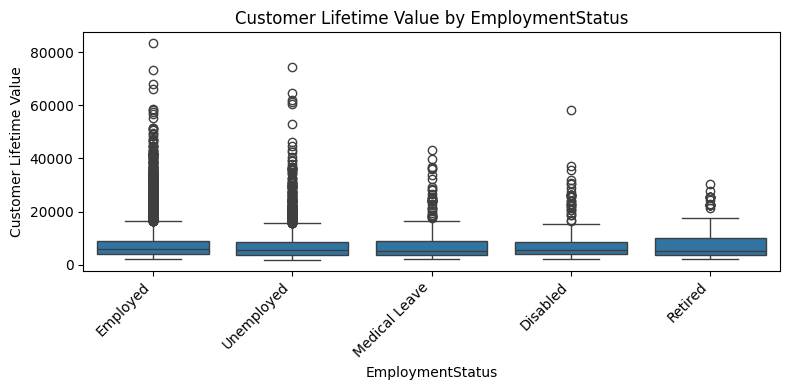

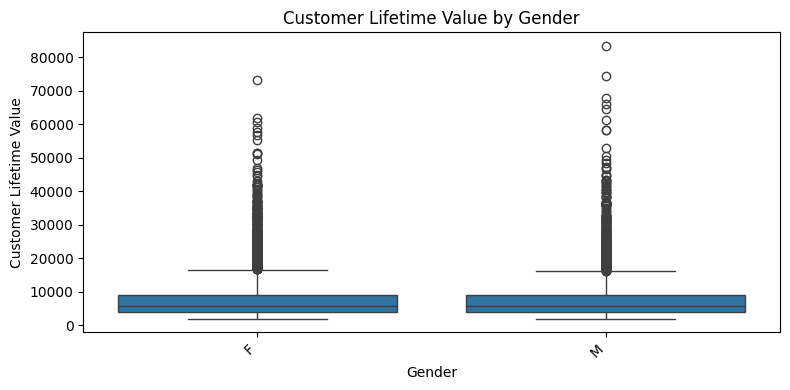

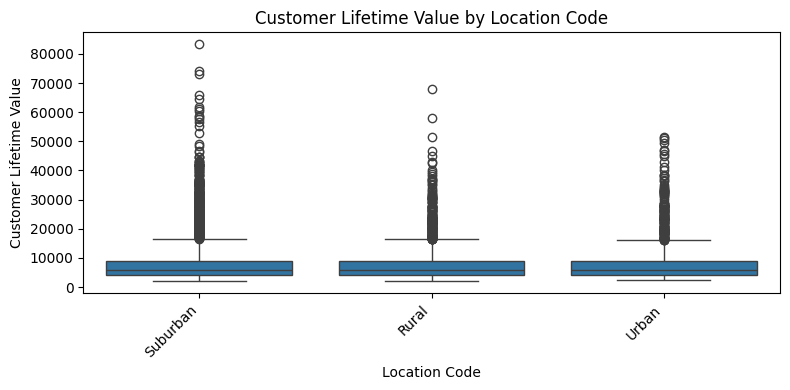

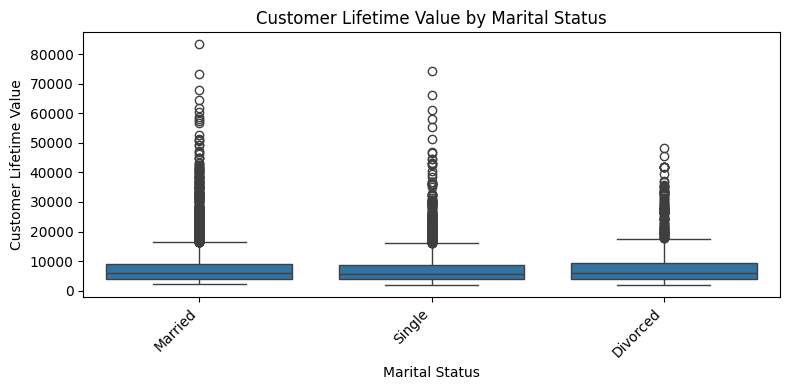

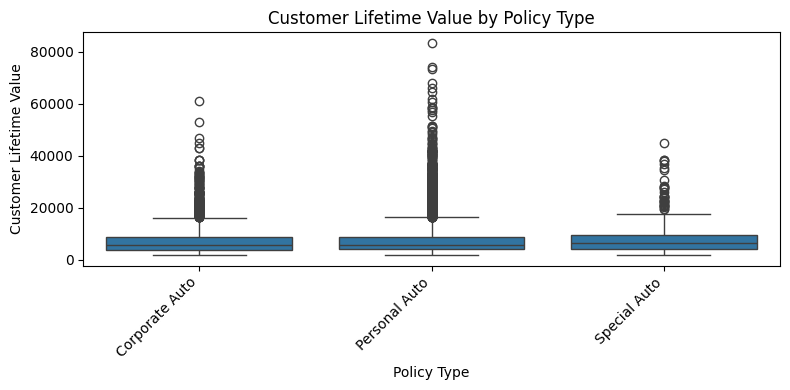

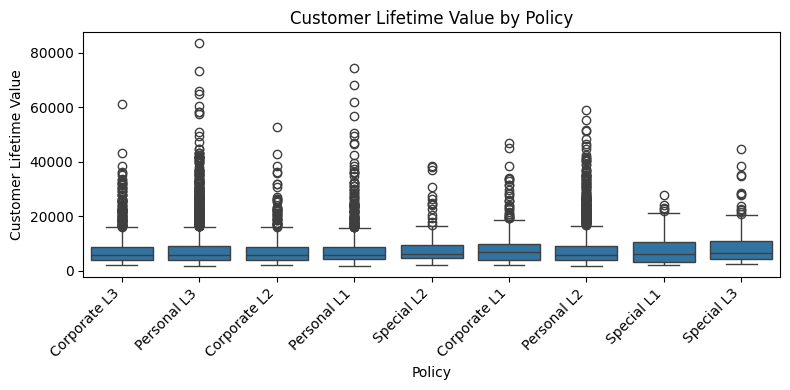

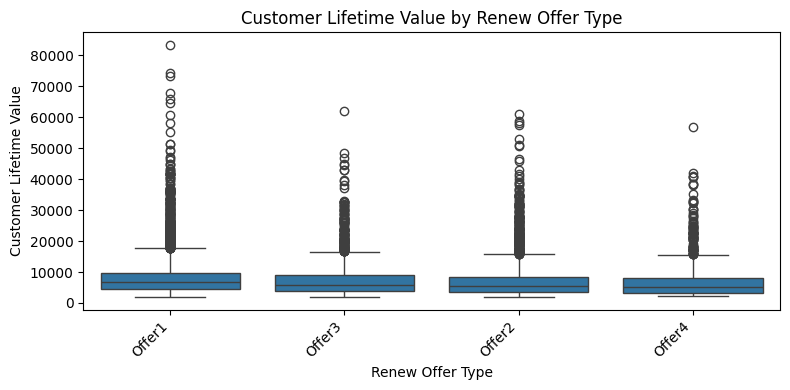

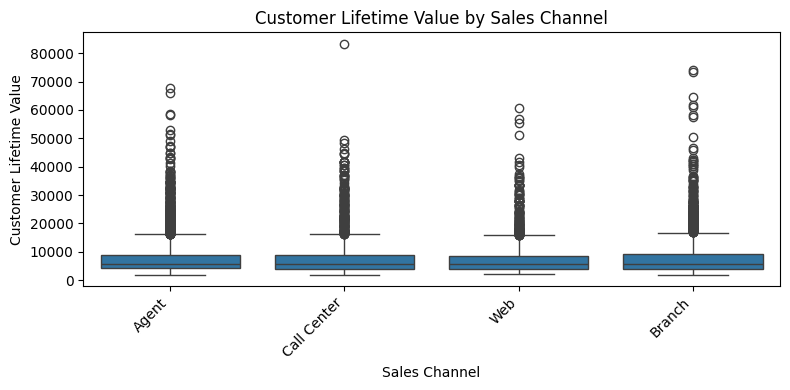

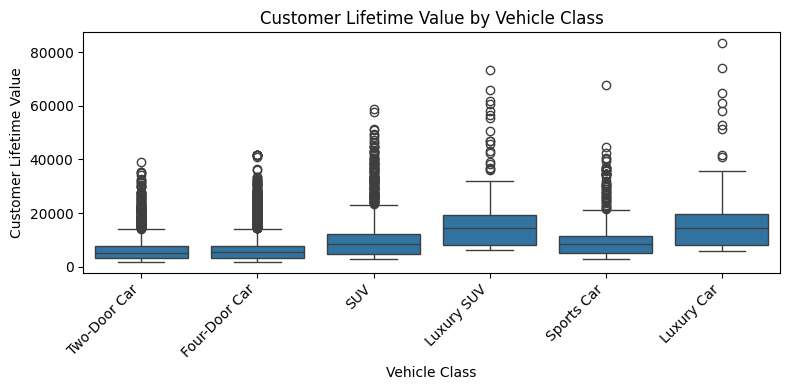

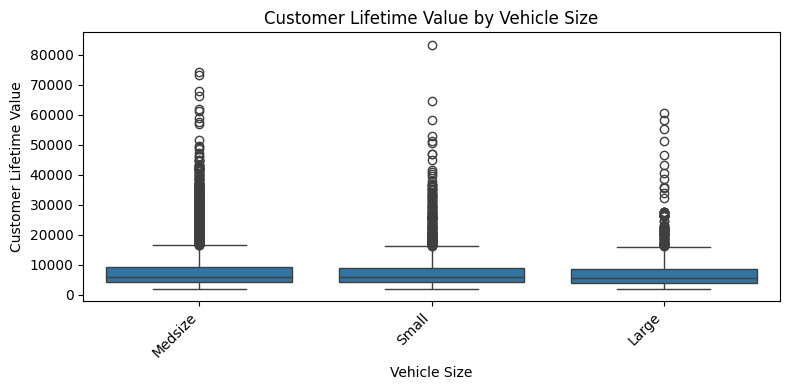

In [23]:
# --- Boxplot: Customer Lifetime Value vs each categorical column ---
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=col, y='Customer Lifetime Value', data=df)
    plt.title(f'Customer Lifetime Value by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

array([[<Axes: title={'center': 'Customer Lifetime Value'}>,
        <Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Monthly Premium Auto'}>],
       [<Axes: title={'center': 'Months Since Last Claim'}>,
        <Axes: title={'center': 'Months Since Policy Inception'}>,
        <Axes: title={'center': 'Number of Open Complaints'}>],
       [<Axes: title={'center': 'Number of Policies'}>,
        <Axes: title={'center': 'Total Claim Amount'}>, <Axes: >]],
      dtype=object)

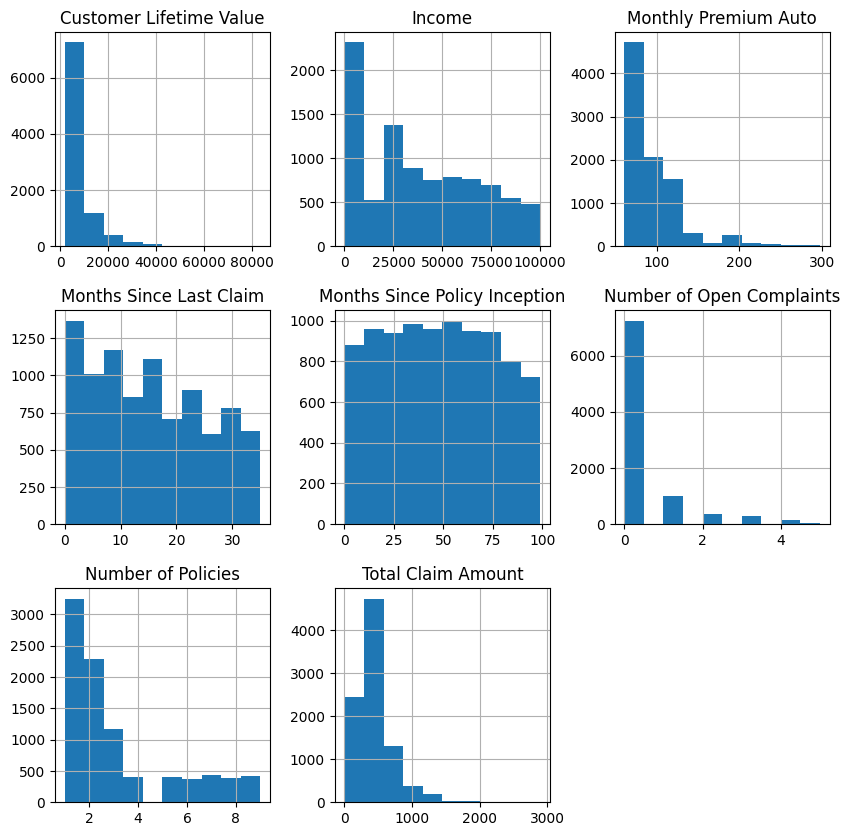

In [24]:
df.hist(figsize=(10,10))

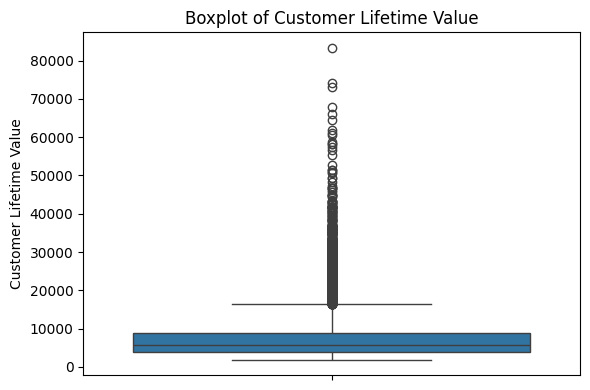

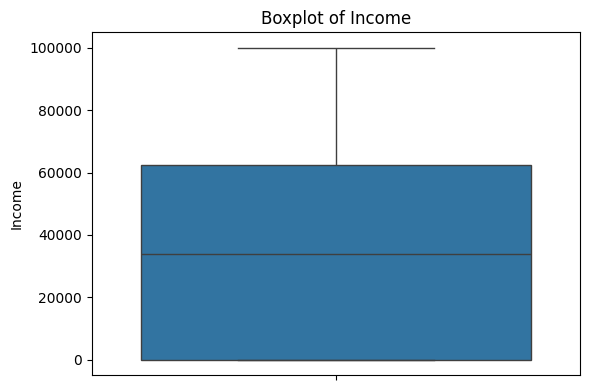

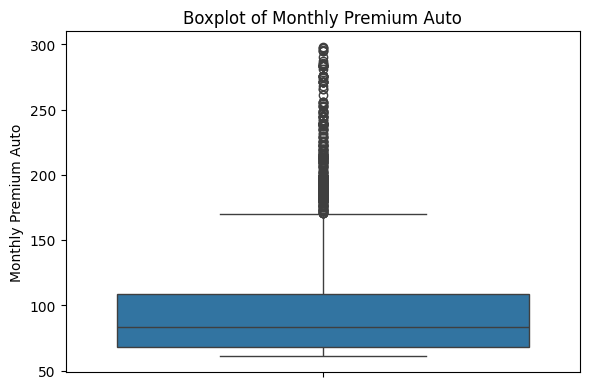

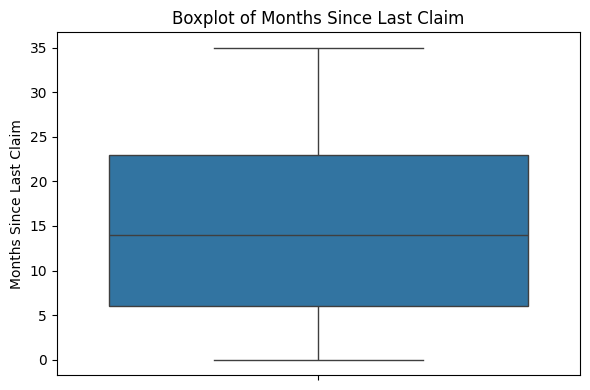

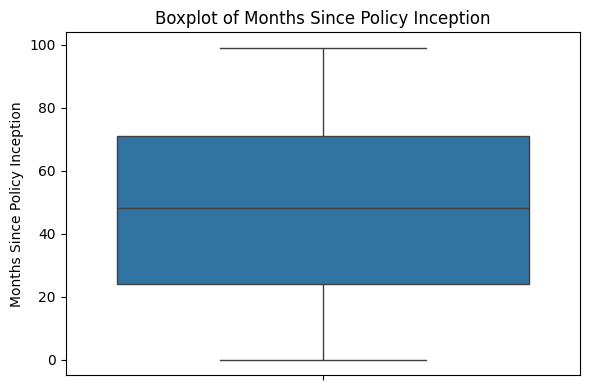

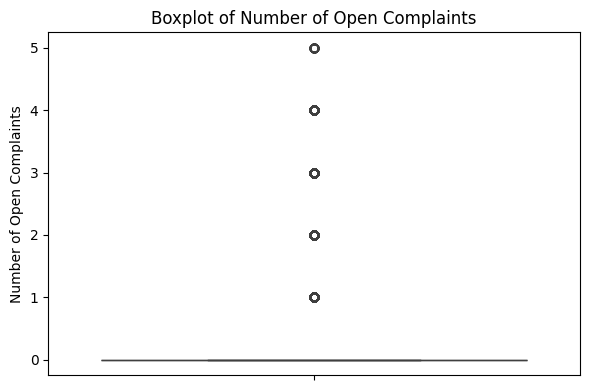

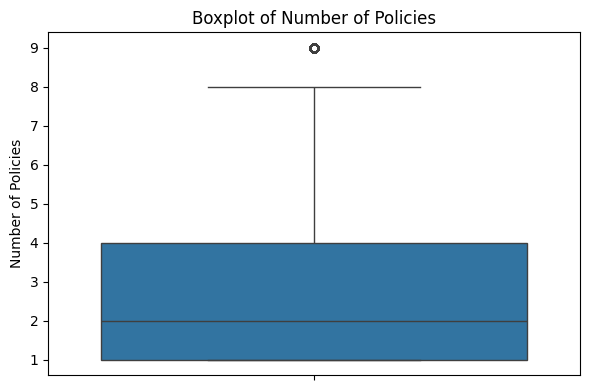

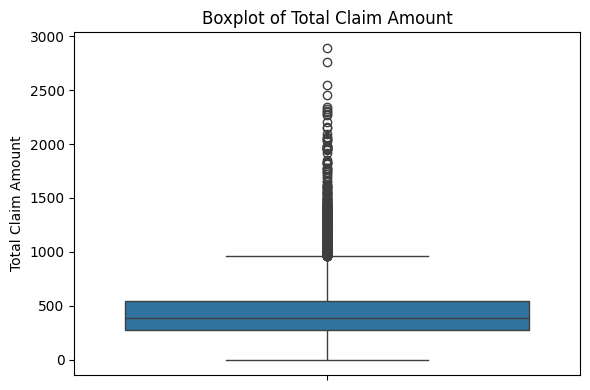

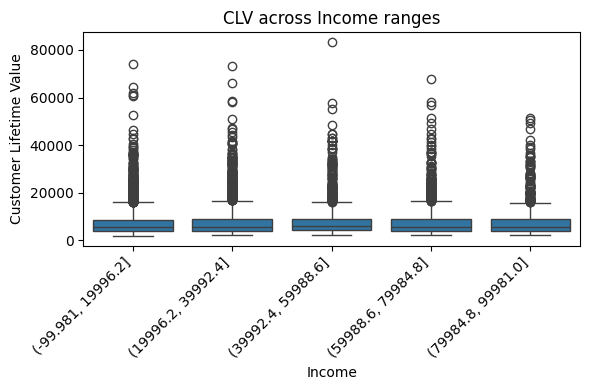

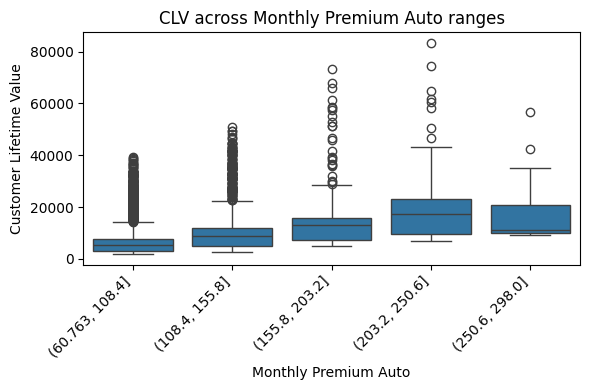

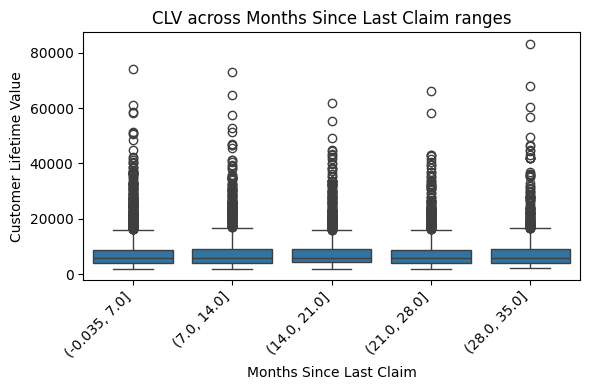

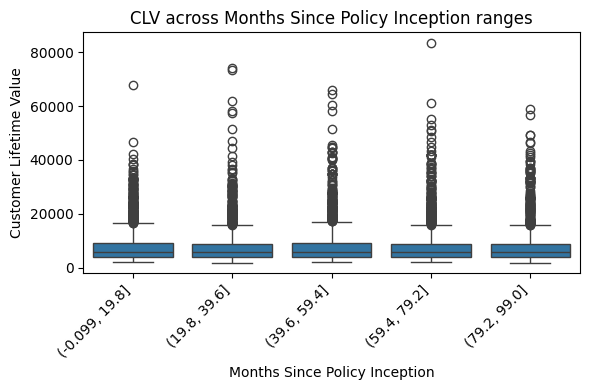

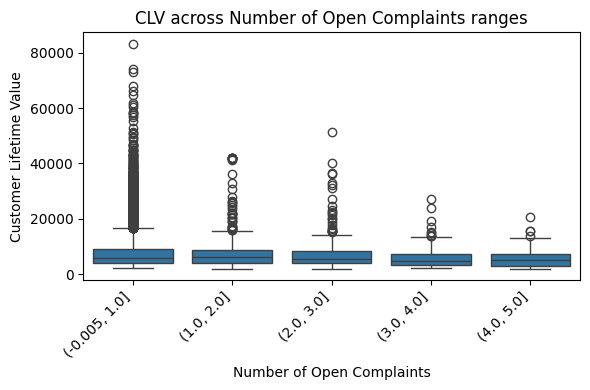

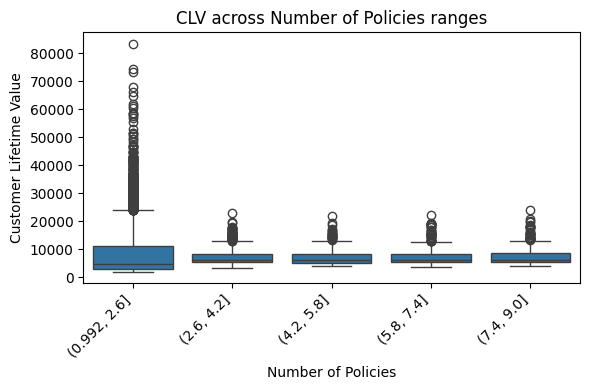

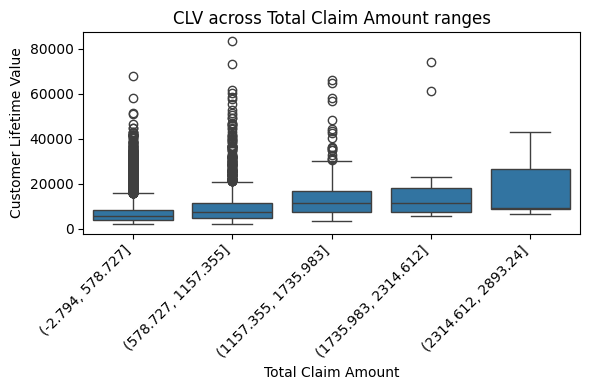

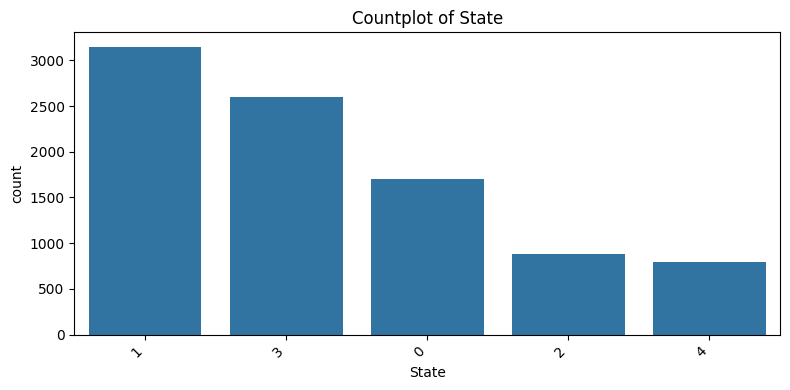

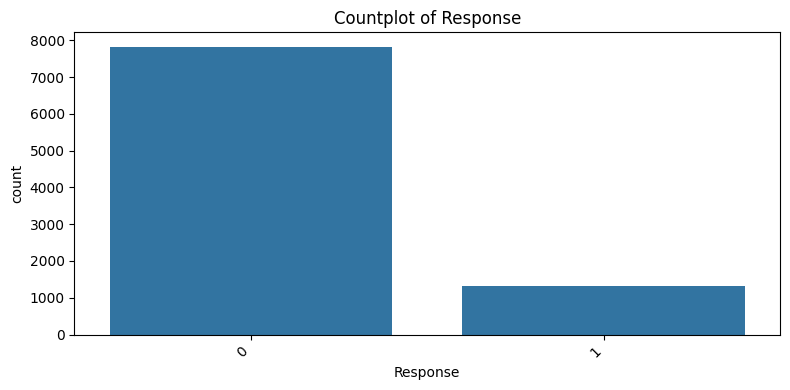

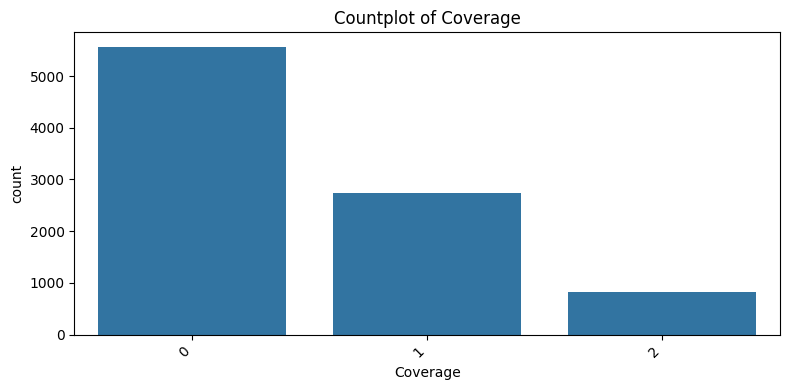

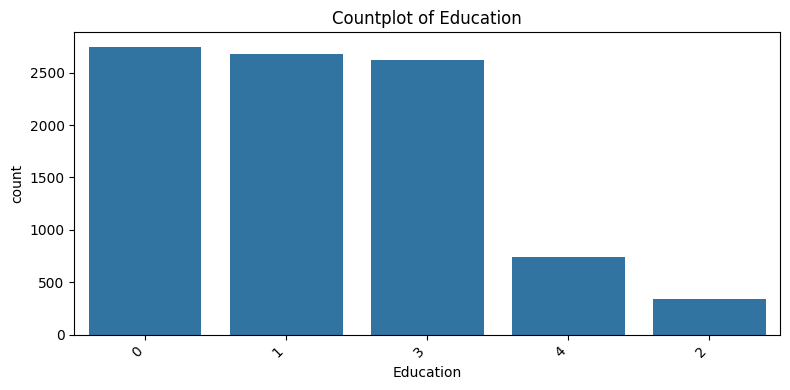

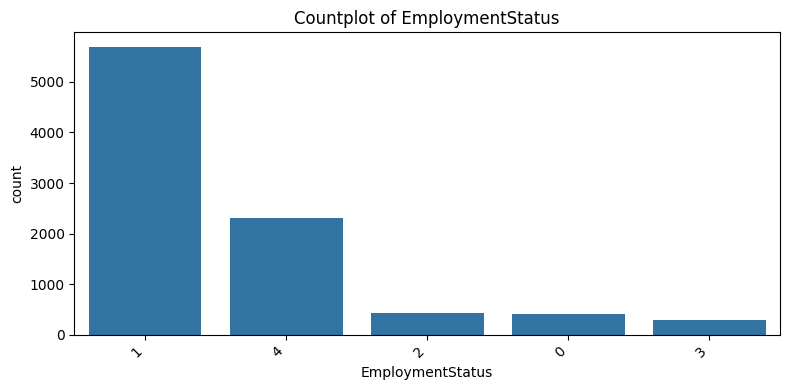

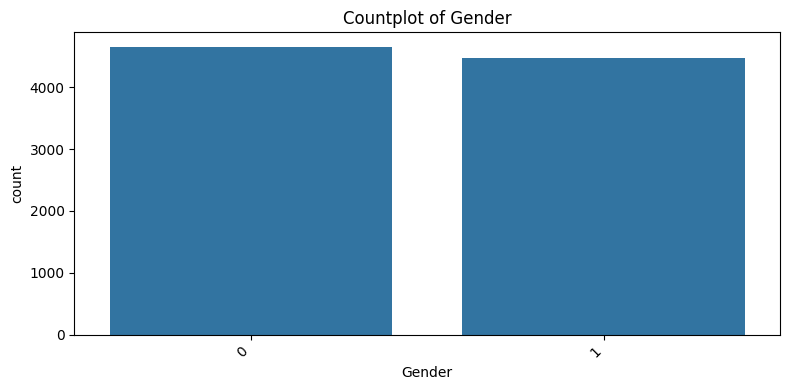

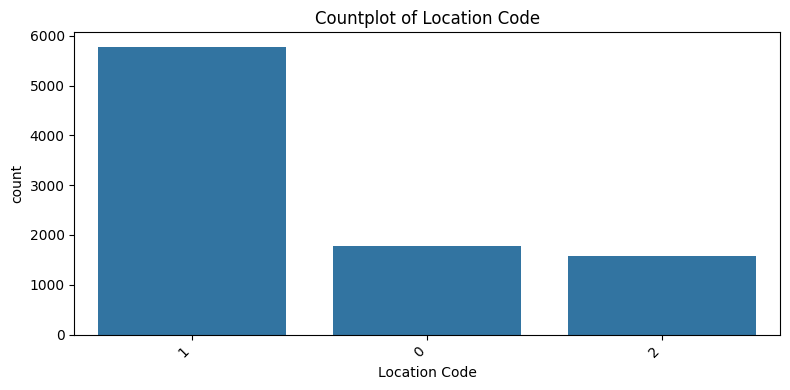

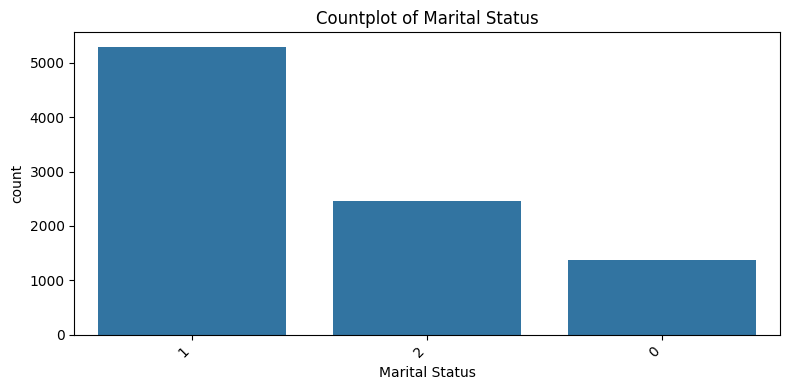

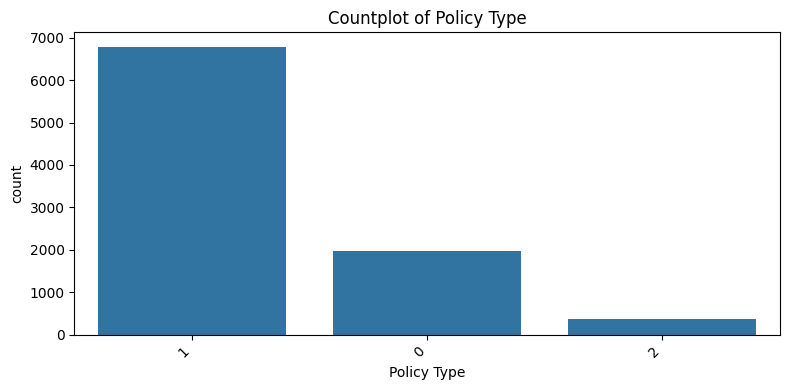

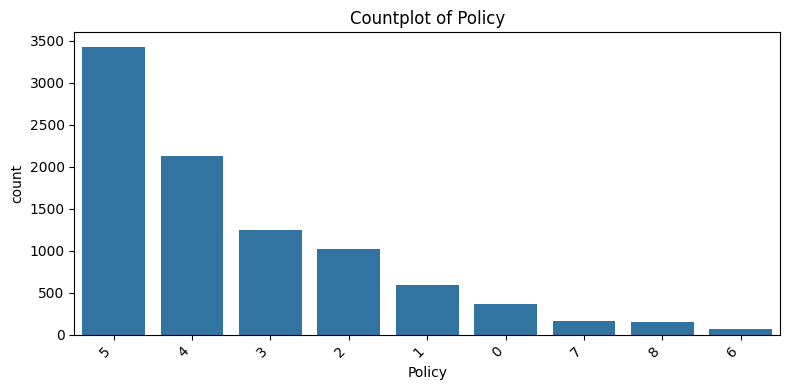

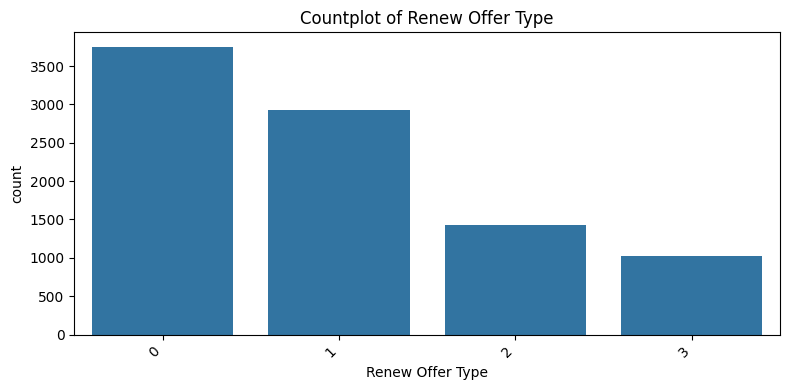

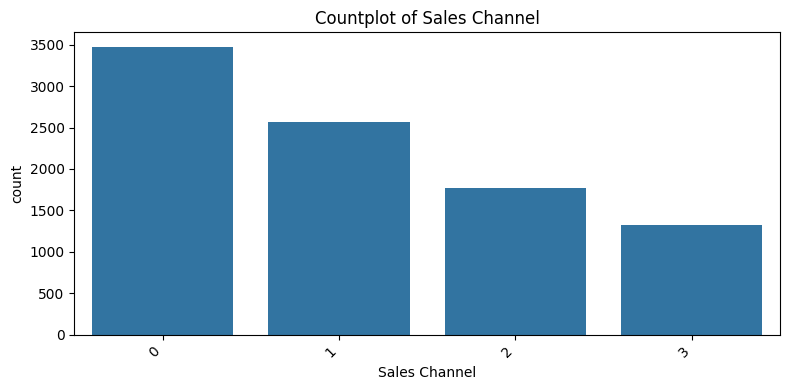

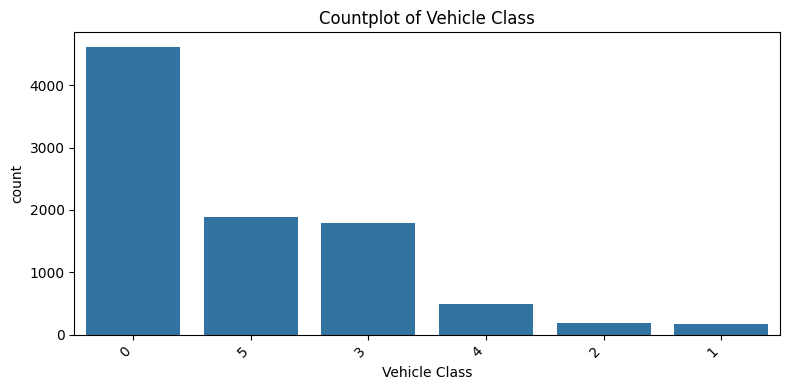

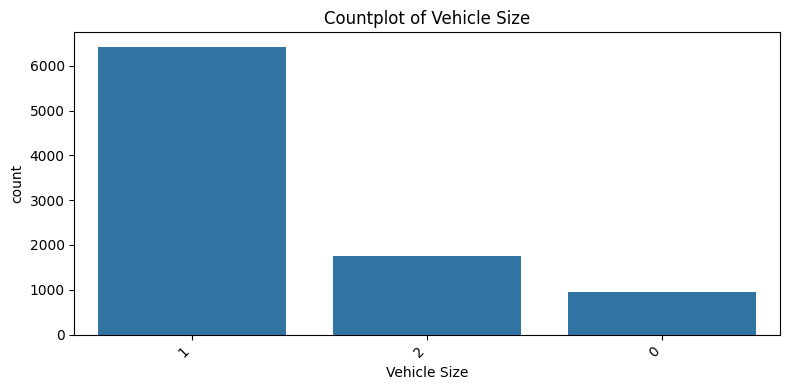

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Boxplot for all numerical columns (own distribution) ---
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

# --- Boxplot: Customer Lifetime Value vs each numerical column (binned) ---
for col in numerical_cols:
    if col != 'Customer Lifetime Value':
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=pd.cut(df[col], bins=5), y='Customer Lifetime Value', data=df)
        plt.title(f'CLV across {col} ranges')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# --- Countplot for all categorical columns (own distribution) ---
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
cat_cols=["Loan_Status","Married","Gender","Dependents","Education","Self_Employed","Property_Area"]
for col in cat_cols:
  df[col]=le.fit_transform(df[col])

In [27]:
# show all categorical columns
print(df.select_dtypes(include=['object']).columns)

Index(['State', 'Response', 'Coverage', 'Education', 'EmploymentStatus',
       'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Policy',
       'Renew Offer Type', 'Sales Channel', 'Vehicle Class', 'Vehicle Size'],
      dtype='object')


In [28]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
cat_cols=['State', 'Response', 'Coverage', 'Education', 'EmploymentStatus',
       'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Policy',
       'Renew Offer Type', 'Sales Channel', 'Vehicle Class', 'Vehicle Size']
for col in cat_cols:
  df[col]=le.fit_transform(df[col])

In [29]:
df.sample(10)

,State,Customer Lifetime Value,Response,Coverage,Education,EmploymentStatus,Gender,Income,Location Code,Marital Status,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
4340,3,3173.032243,0,2,1,4,1,0,1,1,...,52,4,1,1,5,0,2,484.800000,0,2
3176,0,4014.453113,1,1,2,1,0,37384,1,1,...,17,0,1,1,5,1,0,475.200000,0,1
1929,4,3189.667030,0,1,0,4,0,0,1,2,...,3,0,1,1,4,1,1,760.428495,0,1
7990,3,10179.717040,1,2,0,3,0,14290,1,1,...,40,0,1,1,5,0,0,1300.800000,2,1
4586,0,19278.817150,0,0,3,4,0,0,1,2,...,77,0,2,1,5,2,1,366.604732,5,1
8772,1,3045.058130,0,1,3,1,0,53441,1,1,...,78,0,1,1,5,3,0,364.800000,5,1
4683,0,6259.510365,0,1,4,1,0,37813,0,1,...,26,1,5,0,1,0,0,39.781368,0,1
5844,0,7679.677721,0,0,3,0,1,12677,1,1,...,18,0,9,1,5,0,2,500.633484,3,1
6333,1,8622.835375,1,0,0,1,1,97361,1,2,...,85,0,2,1,4,0,0,350.400000,0,1
87,1,2683.470677,0,0,0,1,0,48269,2,1,...,79,3,1,0,1,2,3,282.151207,0,1


In [30]:
from sklearn.model_selection import train_test_split
#df=pd.read_csv("/content/loan_prediction.csv")
Y=df["Customer Lifetime Value"]
X=df.drop(["Customer Lifetime Value"],axis=1)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3)

In [36]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score
model_lr=LinearRegression()
model_lr.fit(X_train,Y_train)
print(model_lr.score(X_train,Y_train))
print(model_lr.score(X_test,Y_test))


0.1608728304661179
0.17286923796260756


In [37]:
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor()
model_knn.fit(X_train, Y_train)
print(model_knn.score(X_train, Y_train))
print(model_knn.score(X_test, Y_test))

0.334233274230864
0.02874765241402666


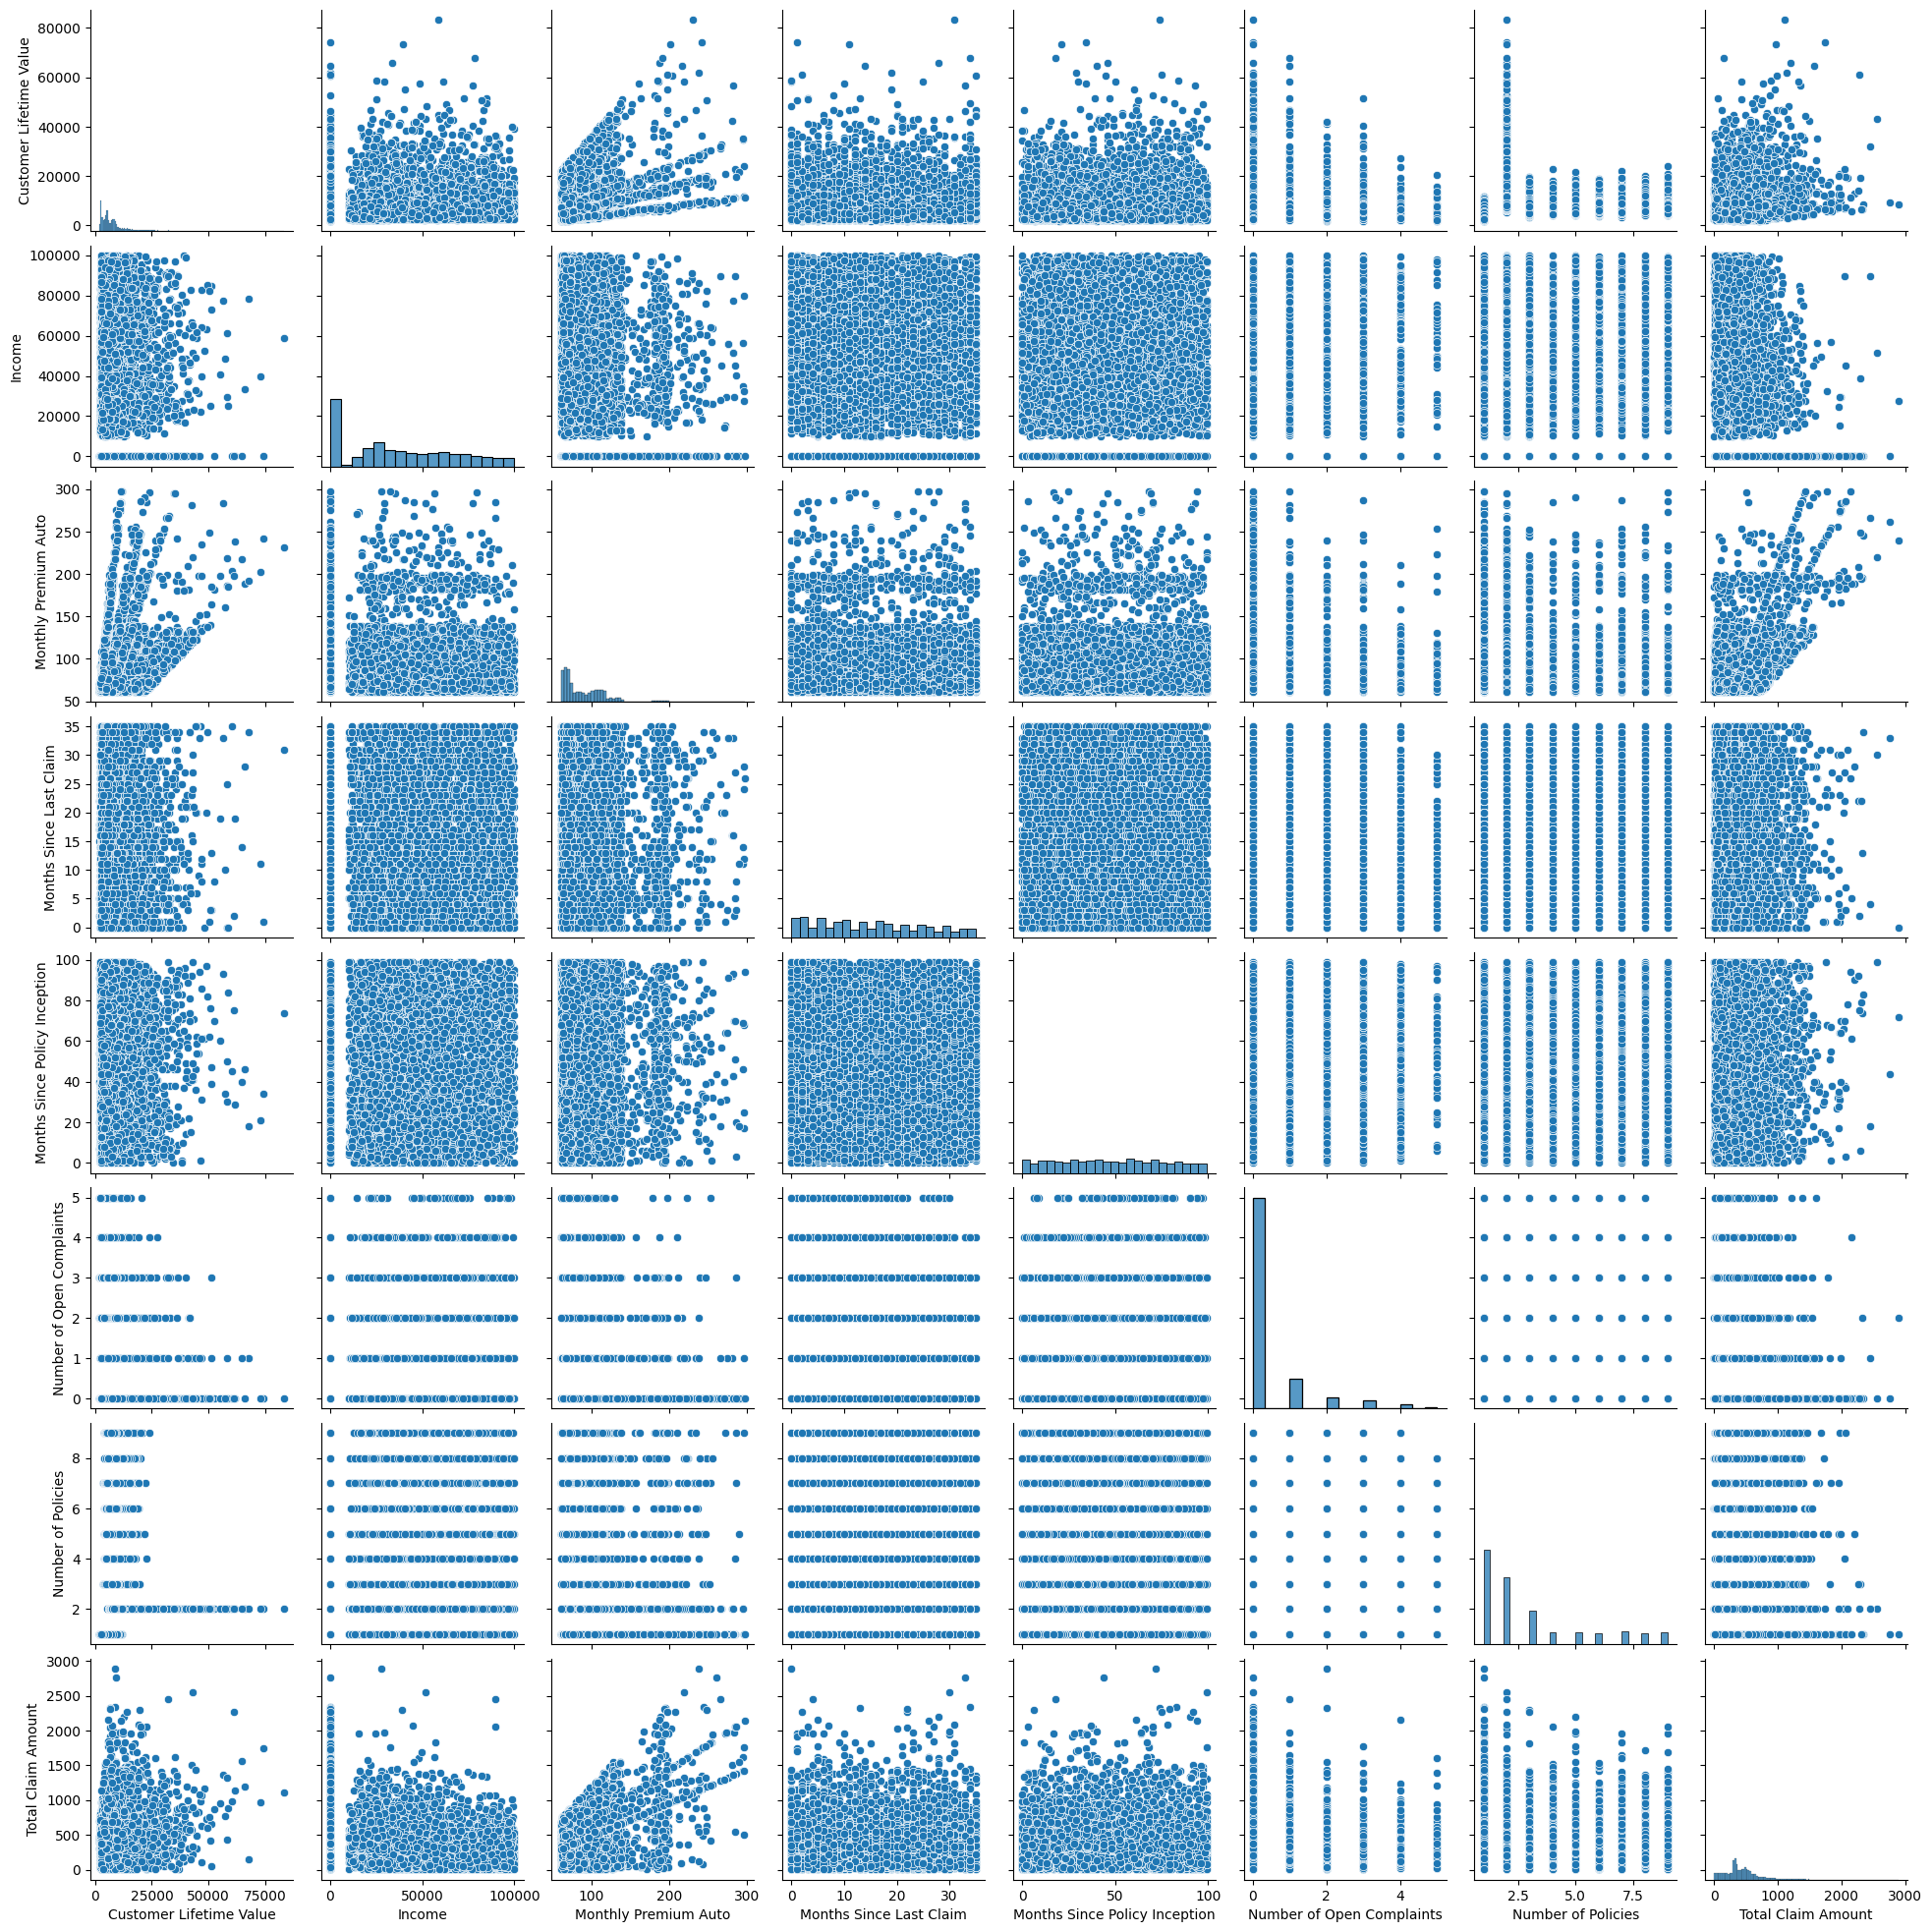

In [39]:
sns.pairplot(df[numerical_cols])
plt.show()

In [40]:
from sklearn.svm import SVR

model_svr = SVR()
model_svr.fit(X_train, Y_train)
print(model_svr.score(X_train, Y_train))
print(model_svr.score(X_test, Y_test))

-0.1056039048396682
-0.11868782306170855


In [42]:
from sklearn.tree import DecisionTreeRegressor

model_dtr = DecisionTreeRegressor()
model_dtr.fit(X_train, Y_train)
print(model_dtr.score(X_train, Y_train))
print(model_dtr.score(X_test, Y_test))

1.0
0.46510429960103195


In [43]:
from sklearn.ensemble import BaggingRegressor

model_bag = BaggingRegressor()
model_bag.fit(X_train, Y_train)
print(model_bag.score(X_train, Y_train))
print(model_bag.score(X_test, Y_test))

0.9441091209986572
0.6825109941871712


In [44]:
from sklearn.ensemble import AdaBoostRegressor

model_ada = AdaBoostRegressor()
model_ada.fit(X_train, Y_train)
print(model_ada.score(X_train, Y_train))
print(model_ada.score(X_test, Y_test))

0.37355263833524155
0.3498941754808571


In [45]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor()
model_rf.fit(X_train, Y_train)
print(model_rf.score(X_train, Y_train))
print(model_rf.score(X_test, Y_test))

0.956433043596684
0.7190477077282209


In [47]:
from sklearn.model_selection import train_test_split
#df=pd.read_csv("/content/loan_prediction.csv")
Y=df["Customer Lifetime Value"]
X=df.drop(["Customer Lifetime Value"],axis=1)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3)

model_lr=LinearRegression()
model_lr.fit(X_train,Y_train)
print(model_lr.score(X_train,Y_train))
print(model_lr.score(X_test,Y_test))



0.16233197538046884
0.16640159388810383


In [49]:
from sklearn.model_selection import train_test_split
#df=pd.read_csv("/content/loan_prediction.csv")
Y=df["Customer Lifetime Value"]
X=df.drop(["Customer Lifetime Value"],axis=1)
#X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3)
Y_log = np.log1p(Y)
X_train_log, X_test_log, Y_train_log, Y_test_log = train_test_split(X, Y_log, test_size=0.3, random_state=42)
model_lr=LinearRegression()
model_lr.fit(X_train_log,Y_train_log)
print(model_lr.score(X_train_log,Y_train_log))
print(model_lr.score(X_test_log,Y_test_log))

0.25009766210442397
0.24568071221395826


In [50]:
model_knn = KNeighborsRegressor()
model_knn.fit(X_train_log,Y_train_log)
print(model_knn.score(X_train_log,Y_train_log))
print(model_knn.score(X_test_log,Y_test_log))

0.36515710231299436
0.07354591370134889


In [51]:
model_svr = SVR()
model_svr.fit(X_train_log,Y_train_log)
print(model_svr.score(X_train_log,Y_train_log))
print(model_svr.score(X_test_log,Y_test_log))

0.03314767644158534
0.030350398312718463


In [53]:
model_dtr = DecisionTreeRegressor()
model_dtr.fit(X_train_log,Y_train_log)
print(model_dtr.score(X_train_log,Y_train_log))
print(model_dtr.score(X_test_log,Y_test_log))

1.0
0.8447332063096313


In [57]:
model_bag = BaggingRegressor()
model_bag.fit(X_train_log,Y_train_log)
print(model_bag.score(X_train_log,Y_train_log))
print(model_bag.score(X_test_log,Y_test_log))

0.983184516751147
0.9033270084734369


In [58]:
model_ada = AdaBoostRegressor()
model_ada.fit(X_train_log,Y_train_log)
print(model_ada.score(X_train_log,Y_train_log))
print(model_ada.score(X_test_log,Y_test_log))

0.8342679245353153
0.8439552160829952


In [59]:
model_rf = RandomForestRegressor()
model_rf.fit(X_train_log,Y_train_log)
print(model_rf.score(X_train_log,Y_train_log))
print(model_rf.score(X_test_log,Y_test_log))

0.9871885333884545
0.9126280697549318


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

model_knn = KNeighborsRegressor()
model_knn.fit(X_train_log,Y_train_log)
print(model_knn.score(X_train_log,Y_train_log))
print(model_knn.score(X_test_log,Y_test_log))

model_svr = SVR()
model_svr.fit(X_train_scaled, Y_train_log)
print(model_svr.score(X_train_scaled, Y_train_log))
print(model_svr.score(X_test_scaled, Y_test_log))

for k in [3, 5, 7, 10, 15]:
    model_knn = KNeighborsRegressor(n_neighbors=k)
    model_knn.fit(X_train_scaled, Y_train_log)
    print(k, model_knn.score(X_train_scaled, Y_train_log), model_knn.score(X_test_scaled, Y_test_log))

0.36515710231299436
0.07354591370134889
0.5694599764040156
0.42780700315672815
3 0.5430702447729256 0.12718420788186513
5 0.45278105136852864 0.1838789340383743
7 0.3977683190722435 0.1931028059571971
10 0.34893054311263616 0.1937344000228094
15 0.31431586968455383 0.21091438464859935


In [63]:
model_dtr = DecisionTreeRegressor(max_depth=6, min_samples_split=10, min_samples_leaf=5)
model_dtr.fit(X_train_log, Y_train_log)
print(model_dtr.score(X_train_log, Y_train_log))
print(model_dtr.score(X_test_log, Y_test_log))

0.9042640745088346
0.8949800973572619


In [64]:
model_rf = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5, random_state=42)
model_rf.fit(X_train_log, Y_train_log)
print(model_rf.score(X_train_log, Y_train_log))
print(model_rf.score(X_test_log, Y_test_log))

0.9256466110981315
0.9058021119802074


In [65]:
model_bag = BaggingRegressor(n_estimators=100, max_samples=0.7, max_features=0.7, random_state=42)
model_bag.fit(X_train_log, Y_train_log)
print(model_bag.score(X_train_log, Y_train_log))
print(model_bag.score(X_test_log, Y_test_log))

0.9562093982268822
0.8295899953280923


In [66]:
from sklearn.ensemble import RandomForestRegressor

# Train the model (as you already have)
model_rf = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5, random_state=42)
model_rf.fit(X_train_log, Y_train_log)
print(model_rf.score(X_train_log, Y_train_log))
print(model_rf.score(X_test_log, Y_test_log))

# --- Predict on the FULL dataset (X), not just X_test ---
predictions_log = model_rf.predict(X)

# --- Reverse the log transform to get actual CLV values ---
predictions_actual = np.expm1(predictions_log)

# --- Add predicted column right next to Customer Lifetime Value ---
clv_index = df.columns.get_loc('Customer Lifetime Value')
df.insert(clv_index + 1, 'Predicted_Value', predictions_actual)

# --- Check it looks right ---
print(df[['Customer Lifetime Value', 'Predicted_Value']].head())

# --- Save to CSV ---
df.to_csv('clv_predictions.csv', index=False)

0.9256466110981315
0.9058021119802074
   Customer Lifetime Value  Predicted_Value
0              2763.519279      2725.388380
1              6979.535903      6866.287418
2             12887.431650     16245.534897
3              7645.861827      7737.897061
4              2813.692575      2874.975544


In [67]:
from sklearn.tree import DecisionTreeRegressor

# Train the model
model_dtr = DecisionTreeRegressor(max_depth=6, min_samples_split=10, min_samples_leaf=5, random_state=42)
model_dtr.fit(X_train_log, Y_train_log)
print(model_dtr.score(X_train_log, Y_train_log))
print(model_dtr.score(X_test_log, Y_test_log))

# --- Predict on the FULL dataset ---
predictions_log_dt = model_dtr.predict(X)

# --- Reverse the log transform ---
predictions_actual_dt = np.expm1(predictions_log_dt)

# --- Add predicted column next to Customer Lifetime Value ---
clv_index = df.columns.get_loc('Customer Lifetime Value')
df.insert(clv_index + 1, 'Predicted_Value_DT', predictions_actual_dt)

# --- Check it looks right ---
print(df[['Customer Lifetime Value', 'Predicted_Value_DT']].head())

# --- Save to CSV ---
df.to_csv('clv_predictions_dt.csv', index=False)

0.9042640745088346
0.8949800973572617
   Customer Lifetime Value  Predicted_Value_DT
0              2763.519279         2740.770850
1              6979.535903         7325.395536
2             12887.431650        17935.618386
3              7645.861827         7325.395536
4              2813.692575         2884.503165


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/auto-mpg.csv")

In [ ]:
df.info()
custcolumn=df['Customer']
effectivedatecolumn=df['Effective To Date']
df=df.drop(columns=['Customer','Effective To Date'])